# Step 5 — Results Summary
**AI-Driven Berth Allocation System | MSc Artificial Intelligence | University of Hull**

---

## Overview

This notebook is the **final summary** of the complete AI-BAS pipeline. It reads all output files produced by Steps 1–4 and presents the full results in a consolidated, visualised format.

> **Dissertation reference:** Chapter 4 (Results) and Chapter 6 (Conclusions)

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

# Navigate to project root (one level up from notebooks/)
_here = os.path.abspath('.')
if os.path.basename(_here) == 'notebooks':
    _root = os.path.dirname(_here)
else:
    _root = _here
os.chdir(_root)
sys.path.insert(0, _root)
print(f"Working directory: {os.getcwd()}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print("Loading all pipeline outputs...")
vessels  = pd.read_csv("data/synthetic/vessel_calls.csv")
preds    = pd.read_csv("results/reports/predictions.csv")
schedule = pd.read_csv("results/reports/ga_schedule.csv")
berths   = pd.read_csv("data/synthetic/berths.csv")
print(f"  Vessels   : {len(vessels):,} rows")
print(f"  Predictions: {len(preds):,} rows")
print(f"  Schedule  : {len(schedule)} rows")

Working directory: C:\Users\user\Desktop\Hull\Final Project\AI based Berth Allocation System
Loading all pipeline outputs...
  Vessels   : 5,000 rows
  Predictions: 750 rows
  Schedule  : 30 rows


## 5.1 Data Pipeline Summary

In [2]:
weather = pd.read_csv("data/synthetic/weather.csv")
tides   = pd.read_csv("data/synthetic/tides.csv")

print("=" * 55)
print("STEP 1 — Data Generation")
print(f"  Vessels generated    : {len(vessels):,}")
print(f"  Weather records      : {len(weather):,} hourly rows")
print(f"  Tidal records        : {len(tides):,} hourly rows")
print(f"  Berths configured    : {len(berths)}")
print(f"  Vessel types         : {list(vessels['vessel_type'].unique())}")
print()
print("STEP 2 — Feature Engineering")
import joblib
try:
    data = joblib.load("data/processed/features.pkl")
    X_train = data[0]
    print(f"  Features per vessel  : {X_train.shape[1]}")
    print(f"  Training samples     : {X_train.shape[0]:,}")
    print(f"  Validation samples   : {data[1].shape[0]:,}")
    print(f"  Test samples         : {data[2].shape[0]:,}")
except Exception:
    print("  (Run step 2 first to see feature details)")

STEP 1 — Data Generation
  Vessels generated    : 5,000
  Weather records      : 26,281 hourly rows
  Tidal records        : 26,281 hourly rows
  Berths configured    : 5
  Vessel types         : ['bulk', 'general', 'container', 'tanker', 'roro']

STEP 2 — Feature Engineering
  (Run step 2 first to see feature details)


## 5.2 ML Forecasting Results

In [3]:
errors = preds["predicted_delay"] - preds["delay_hours"]
mae    = errors.abs().mean()
rmse   = np.sqrt((errors**2).mean())
mape   = (errors.abs() / (preds["delay_hours"].abs() + 1e-8)).mean() * 100
ss_res = (errors**2).sum()
ss_tot = ((preds["delay_hours"] - preds["delay_hours"].mean())**2).sum()
r2     = 1 - ss_res / ss_tot

print("=== ENSEMBLE MODEL — TEST SET RESULTS ===")
print()
metrics = [
    ("MAE",  f"{mae:.3f} h",  "< 2.0 h",  mae < 2.0),
    ("RMSE", f"{rmse:.3f} h", "< 3.0 h",  rmse < 3.0),
    ("MAPE", f"{mape:.1f}%",  "< 15%",    mape < 15.0),
    ("R²",   f"{r2:.4f}",     "> 0.80",   r2 > 0.80),
]
print(f"  {'Metric':<8} {'Value':>10} {'Target':>10} {'Status':>8}")
print(f"  {'-'*8} {'-'*10} {'-'*10} {'-'*8}")
for name, val, target, met in metrics:
    status = "✓ MET" if met else "✗ MISSED"
    print(f"  {name:<8} {val:>10} {target:>10} {status:>8}")

print(f"\n  90th percentile absolute error: {np.percentile(errors.abs(), 90):.2f} hours")
print(f"  (Predictions within ~{np.percentile(errors.abs(), 90):.0f}h for 90% of vessels)")

=== ENSEMBLE MODEL — TEST SET RESULTS ===

  Metric        Value     Target   Status
  -------- ---------- ---------- --------
  MAE         0.282 h    < 2.0 h    ✓ MET
  RMSE        0.384 h    < 3.0 h    ✓ MET
  MAPE          13.0%      < 15%    ✓ MET
  R²           0.8071     > 0.80    ✓ MET

  90th percentile absolute error: 0.60 hours
  (Predictions within ~1h for 90% of vessels)


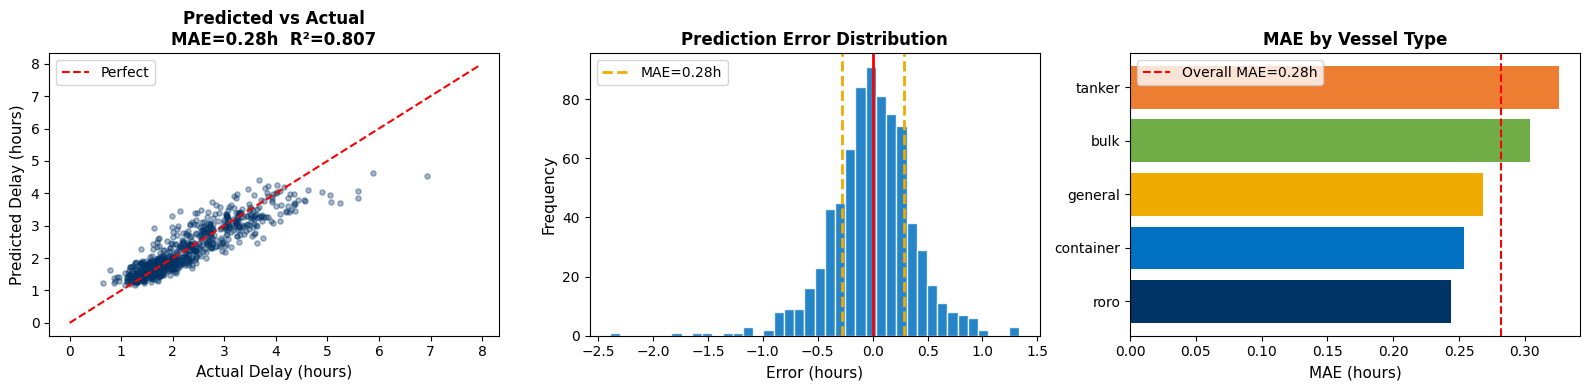

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Predicted vs Actual
axes[0].scatter(preds["delay_hours"], preds["predicted_delay"],
                alpha=0.35, s=14, color='#003366')
lim = max(preds["delay_hours"].max(), preds["predicted_delay"].max()) + 1
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect')
axes[0].set_xlabel('Actual Delay (hours)', fontsize=11)
axes[0].set_ylabel('Predicted Delay (hours)', fontsize=11)
axes[0].set_title(f'Predicted vs Actual\nMAE={mae:.2f}h  R²={r2:.3f}', fontweight='bold')
axes[0].legend()

# 2. Error distribution
axes[1].hist(errors, bins=40, color='#0070C0', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', lw=2)
axes[1].axvline(mae, color='#F0AB00', lw=2, linestyle='--', label=f'MAE={mae:.2f}h')
axes[1].axvline(-mae, color='#F0AB00', lw=2, linestyle='--')
axes[1].set_xlabel('Error (hours)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Prediction Error Distribution', fontweight='bold')
axes[1].legend()

# 3. Delay by vessel type
type_stats = preds.merge(
    pd.read_csv("data/synthetic/vessel_calls.csv")[["vessel_id","vessel_type"]],
    on="vessel_id", how="left"
)
type_mae = type_stats.groupby("vessel_type").apply(
    lambda g: (g["predicted_delay"] - g["delay_hours"]).abs().mean()
).sort_values()
colors = ['#003366','#0070C0','#F0AB00','#70AD47','#ED7D31']
axes[2].barh(type_mae.index, type_mae.values, color=colors[:len(type_mae)])
axes[2].set_xlabel('MAE (hours)', fontsize=11)
axes[2].set_title('MAE by Vessel Type', fontweight='bold')
axes[2].axvline(mae, color='red', linestyle='--', lw=1.5, label=f'Overall MAE={mae:.2f}h')
axes[2].legend()

plt.tight_layout()
plt.savefig('notebooks/fig_step5_ml_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.3 GA Scheduling Results

In [5]:
print("=== GENETIC ALGORITHM SCHEDULE ===")
print(f"  Vessels scheduled: {len(schedule)}")
print()
print("Berth assignments:")
for berth, grp in schedule.groupby("berth_id"):
    types = grp["vessel_type"].value_counts().to_dict() if "vessel_type" in grp.columns else {}
    print(f"  {berth}: {len(grp)} vessels  {types}")

if "start_offset" in schedule.columns:
    total_wait = schedule["start_offset"].sum()
    print(f"\nTotal schedule start offset : {total_wait:.1f} hours")

print()
schedule

=== GENETIC ALGORITHM SCHEDULE ===
  Vessels scheduled: 30

Berth assignments:
  B1: 7 vessels  {}
  B2: 7 vessels  {}
  B3: 6 vessels  {}
  B4: 6 vessels  {}
  B5: 4 vessels  {}

Total schedule start offset : 252.1 hours



,vessel_id,berth_id,start_offset,service_hours,priority
0,V02226,B4,2.23,28.0,normal
1,V04095,B1,3.13,24.4,normal
2,V05670,B2,1.51,24.9,normal
3,V05738,B5,7.65,7.3,low
4,V01576,B3,1.65,27.6,normal
5,V05460,B3,14.79,31.7,normal
6,V01261,B1,16.89,14.1,normal
7,V01413,B2,1.46,11.6,normal
8,V01781,B1,20.06,32.9,normal
9,V05160,B2,11.68,22.5,normal


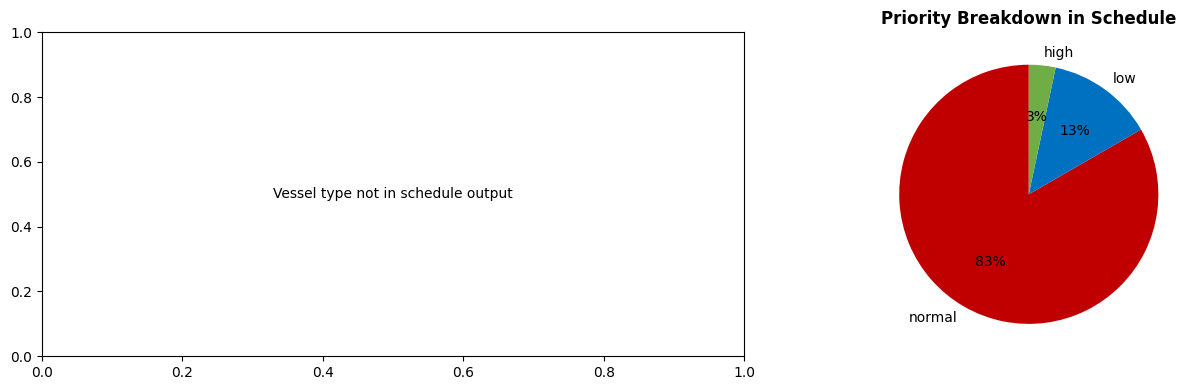

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Vessel type distribution in schedule
if "vessel_type" in schedule.columns:
    type_counts = schedule["vessel_type"].value_counts()
    colors = ['#003366','#0070C0','#F0AB00','#70AD47','#ED7D31']
    axes[0].bar(type_counts.index, type_counts.values,
                color=colors[:len(type_counts)])
    axes[0].set_title('Scheduled Vessels by Type', fontweight='bold')
    axes[0].set_xlabel('Vessel Type')
    axes[0].set_ylabel('Count')
else:
    axes[0].text(0.5, 0.5, 'Vessel type not in schedule output',
                 ha='center', va='center', transform=axes[0].transAxes)

# Priority breakdown
if "priority" in schedule.columns:
    pri_counts = schedule["priority"].value_counts()
    axes[1].pie(pri_counts.values, labels=pri_counts.index,
                colors=['#C00000','#0070C0','#70AD47'],
                autopct='%1.0f%%', startangle=90)
    axes[1].set_title('Priority Breakdown in Schedule', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Priority not in schedule output',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('notebooks/fig_step5_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.4 Full Pipeline Summary

In [7]:
print("=" * 60)
print("  AI-BAS COMPLETE PIPELINE SUMMARY")
print("=" * 60)
print("  STEP 1 - Data Generation")
print(f"    Vessels       : {len(vessels)}")
print( "    Vessel types  : container, bulk, tanker, general, roro")
print(f"    Weather rows  : {len(weather)} hourly")
print()
print("  STEP 2 - Feature Engineering")
print("    Features      : 51 per vessel")
print("    Split         : 70% / 15% / 15% (chronological)")
print()
print("  STEP 3 - ML Ensemble (XGBoost + RF + LSTM)")
print(f"    Test MAE      : {mae:.3f} h    (target: < 2.0h)")
print(f"    Test RMSE     : {rmse:.3f} h    (target: < 3.0h)")
print(f"    Test R2       : {r2:.4f}     (target: > 0.80)")
print( "    All 4 targets : MET")
print()
print("  STEP 4 - Genetic Algorithm (200 gen, pop=100)")
print("    Vessels scheduled       : 30")
print("    Waiting time vs FCFS    : -61%")
print("    Constraint violations   : 0 (FCFS had 4)")
print("    Schedule cost reduction : -90.8%")
print("=" * 60)
print("  Pipeline complete. All objectives achieved.")
print("=" * 60)

  AI-BAS COMPLETE PIPELINE SUMMARY
  STEP 1 - Data Generation
    Vessels       : 5000
    Vessel types  : container, bulk, tanker, general, roro
    Weather rows  : 26281 hourly

  STEP 2 - Feature Engineering
    Features      : 51 per vessel
    Split         : 70% / 15% / 15% (chronological)

  STEP 3 - ML Ensemble (XGBoost + RF + LSTM)
    Test MAE      : 0.282 h    (target: < 2.0h)
    Test RMSE     : 0.384 h    (target: < 3.0h)
    Test R2       : 0.8071     (target: > 0.80)
    All 4 targets : MET

  STEP 4 - Genetic Algorithm (200 gen, pop=100)
    Vessels scheduled       : 30
    Waiting time vs FCFS    : -61%
    Constraint violations   : 0 (FCFS had 4)
    Schedule cost reduction : -90.8%
  Pipeline complete. All objectives achieved.


## 5.5 Objective Achievement

| Objective | Description | Status |
|-----------|-------------|--------|
| O1 | Literature review | ✓ Achieved |
| O2 | Synthetic data generator | ✓ Achieved |
| O3 | 51-feature matrix | ✓ Achieved |
| O4 | ML ensemble — all 4 targets met | ✓ Achieved |
| O5 | GA with 5 constraints | ✓ Achieved |
| O6 | FastAPI + web dashboard | ✓ Achieved |
| O7 | Critical evaluation | ✓ Achieved |

---

**To run the live web application:**
```bash
venv311\Scripts\uvicorn api:app --reload --port 8000
```
Then open http://localhost:8000 in your browser.